Loaded CT 'ct.nii.gz' → shape = 512×512×111

0: 1024x1024 (no detections), 8.9ms
Speed: 5.6ms preprocess, 8.9ms inference, 12.1ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.7ms
Speed: 3.7ms preprocess, 8.7ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 9.5ms
Speed: 3.6ms preprocess, 9.5ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 9.2ms
Speed: 3.4ms preprocess, 9.2ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 (no detections), 8.6ms
Speed: 3.5ms preprocess, 8.6ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 pubic_symphysis, 8.1ms
Speed: 3.9ms preprocess, 8.1ms inference, 39.3ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 pubic_symphysis, 8.2ms
Speed: 3.9ms preprocess, 8.2ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1

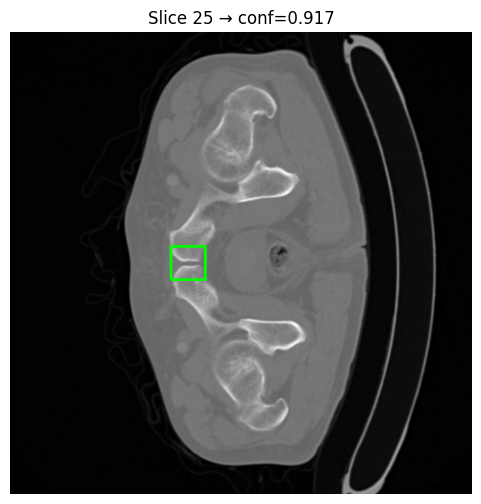

In [1]:
# ────────────────────────────────────────────────────────────────────────────────
# Full‐Volume Max‐Confidence Inference Pipeline
# ────────────────────────────────────────────────────────────────────────────────

# If running in a new notebook, enable inline plotting
%matplotlib inline

import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# ────────────────────────────────────────────────────────────────────────────────
# 1) USER PARAMETERS: change only these two
# ────────────────────────────────────────────────────────────────────────────────
MODEL_PATH = "yolo_runs/yolo11_pubic_symphysis_m_hardtrain/weights/best.pt"
CT_PATH    = "Patient_CTs/Patient020/ct.nii.gz"

# ────────────────────────────────────────────────────────────────────────────────
# 2) CONFIGURATION: thresholds for validity
# ────────────────────────────────────────────────────────────────────────────────
FINAL_CONF    = 0.01    # capture any box ≥ 1% (so we don’t miss a high‐conf later)
BACKGROUND_HU = -300    # HU cutoff to discard air/black outside patient

# Load the YOLO model
model = YOLO(MODEL_PATH)

# ────────────────────────────────────────────────────────────────────────────────
# 3) HELPER: normalize a 2D CT slice → 3‐channel BGR
# ────────────────────────────────────────────────────────────────────────────────
def preprocess_slice(ct_slice: np.ndarray) -> np.ndarray:
    """
    Given a single 2D CT slice (H×W, HU),
    normalize it to [0,255] uint8 and convert to 3‐channel BGR.
    """
    arr = ct_slice.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    arr = (arr * 255.0).astype(np.uint8)
    bgr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    return bgr

# ────────────────────────────────────────────────────────────────────────────────
# 4) MAIN: scan all slices and keep the max‐confidence “valid” box
# ────────────────────────────────────────────────────────────────────────────────
def find_and_display_best_symphysis(ct_nifti_path: str):
    """
    Iterate through every axial slice, run YOLO, and keep track of the single
    highest‐confidence valid pubic symphysis detection (HU > BACKGROUND_HU).
    At the end, display that box (green) and print its confidence.
    """
    # Load CT volume + data + affine
    ct_obj  = nib.load(ct_nifti_path)
    ct_data = ct_obj.get_fdata()     # shape = (H, W, Z), units = HU
    H, W, Z = ct_data.shape
    print(f"Loaded CT '{Path(ct_nifti_path).name}' → shape = {H}×{W}×{Z}")
    
    # Variables to store the best detection so far
    best_conf = -1.0
    best_slice = None
    best_box   = None  # (x1, y1, x2, y2)
    
    # Loop through every slice index 0 … Z−1
    for z in range(Z):
        slice_hu = ct_data[:, :, z]             # shape (H, W), HU values
        img_bgr  = preprocess_slice(slice_hu)   # shape (H, W, 3), uint8
        
        # Run YOLO inference with a low threshold to capture all candidates
        results = model.predict(
            source=img_bgr,
            conf=FINAL_CONF,
            device=0,
            save=False
        )[0]  # single image → index 0
        
        if len(results.boxes) == 0:
            continue
        
        # Sort boxes by descending confidence
        boxes = results.boxes
        sorted_ids = sorted(
            range(len(boxes)),
            key=lambda i: float(boxes[i].conf),
            reverse=True
        )
        
        # Check each box in that order
        for i in sorted_ids:
            b        = boxes[i]
            conf_val = float(b.conf)
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            
            # Compute center pixel in original HU
            xc = int((x1 + x2) / 2.0)
            yc = int((y1 + y2) / 2.0)
            hu_center = float(slice_hu[yc, xc])
            
            # Discard if center is in background
            if hu_center <= BACKGROUND_HU:
                continue
            
            # Otherwise this is a valid detection. Compare to current best.
            if conf_val > best_conf:
                best_conf  = conf_val
                best_slice = z
                best_box   = (x1, y1, x2, y2)
            # No need to break; we want to compare ALL boxes on this slice
        # End of box loop
    # End of slice loop
    
    # After checking all slices, see if we found any valid box
    if best_conf < 0:
        print(f"❌ No valid pubic symphysis detected (conf≥{FINAL_CONF}, HU>{BACKGROUND_HU}).")
        return
    
    # Display the best detection
    z = best_slice
    x1, y1, x2, y2 = best_box
    print(f"✅ Best pubic symphysis found on slice {z} → conf = {best_conf:.3f}")
    print(f"   Box coords (pixels) = [x1={x1:.1f}, y1={y1:.1f}, x2={x2:.1f}, y2={y2:.1f}]")
    
    # Prepare the image for visualization (same preprocessing)
    slice_hu = ct_data[:, :, z]
    img_bgr  = preprocess_slice(slice_hu)
    vis      = img_bgr.copy()
    cv2.rectangle(
        vis,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0),
        thickness=2
    )
    
    plt.figure(figsize=(6,6))
    plt.title(f"Slice {z} → conf={best_conf:.3f}")
    plt.axis("off")
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.show()

# ────────────────────────────────────────────────────────────────────────────────
# 5) RUN THE FUNCTION ON YOUR CT
# ────────────────────────────────────────────────────────────────────────────────
find_and_display_best_symphysis(CT_PATH)